Image loaded successfully
Number of keypoints detected: 8376


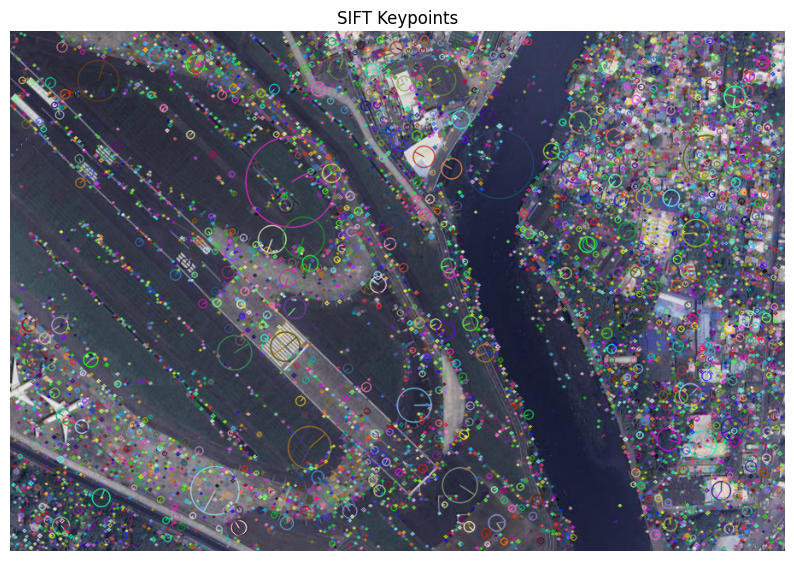

In [58]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD IMAGE =====
img = cv2.imread("runway_original.png")   # <-- change path if needed

if img is None:
    print("Image not found. Check file path.")
else:
    print("Image loaded successfully")

# ===== CONVERT TO GRAYSCALE =====
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = clahe.apply(gray)

# ===== CREATE SIFT OBJECT =====
sift = cv2.SIFT_create() #trying to compare only strong keypoints 

# ===== DETECT KEYPOINTS AND DESCRIPTORS =====
keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of keypoints detected:", len(keypoints))

# ===== DRAW KEYPOINTS =====
img_kp = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# ===== DISPLAY =====
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

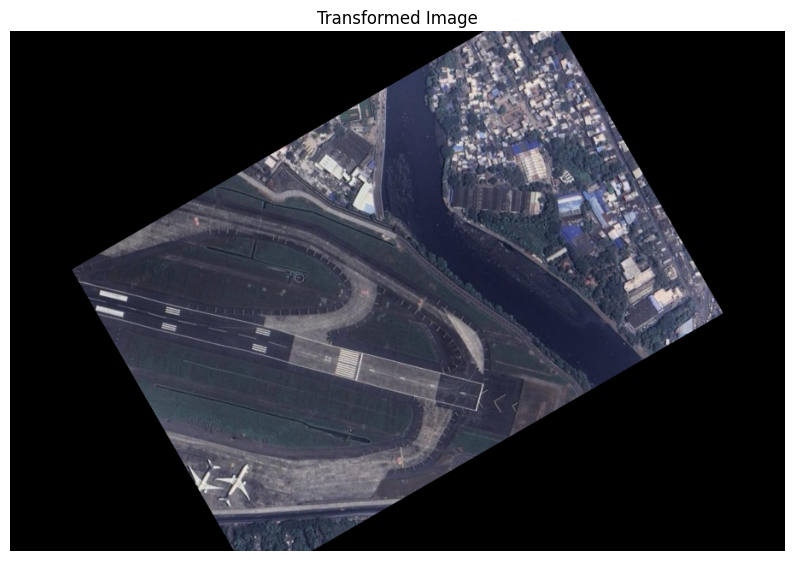

In [59]:
# reload original
img1 = cv2.imread("runway_original.png")
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

h, w = gray1.shape

# ===== TRANSFORMATION =====
angle = 30       # rotation angle
scale = 0.7      # zoom out

M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
img2 = cv2.warpAffine(img1, M, (w, h))

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Transformed Image")
plt.axis("off")
plt.show()

In [60]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("Keypoints Image 1:", len(kp1))
print("Keypoints Image 2:", len(kp2))

Keypoints Image 1: 4670
Keypoints Image 2: 2288


In [61]:
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Total Matches:", len(matches))
print("Good Matches:", len(good_matches))

Total Matches: 4670
Good Matches: 1519


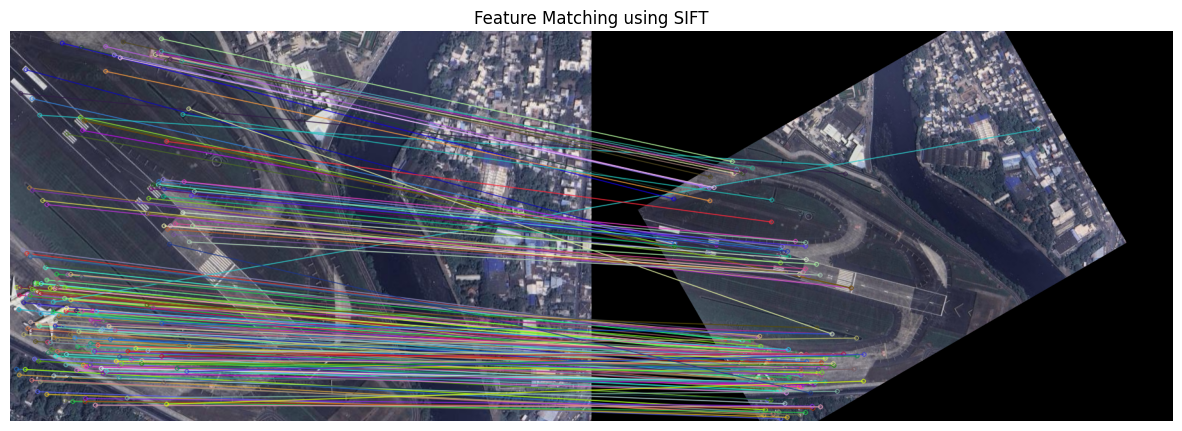

In [62]:
match_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches[:200],   # show first 200 for clarity
    None,
    flags=2
)

plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching using SIFT")
plt.axis("off")
plt.show()

Angle      | Raw Matches     | RANSAC Inliers  | Ratio     
-----------------------------------------------------------------
0          | 1726            | 1542            | 0.893
15         | 1718            | 1527            | 0.889
30         | 1667            | 1479            | 0.887
45         | 1609            | 1423            | 0.884
60         | 1550            | 1365            | 0.881
90         | 1647            | 1467            | 0.891


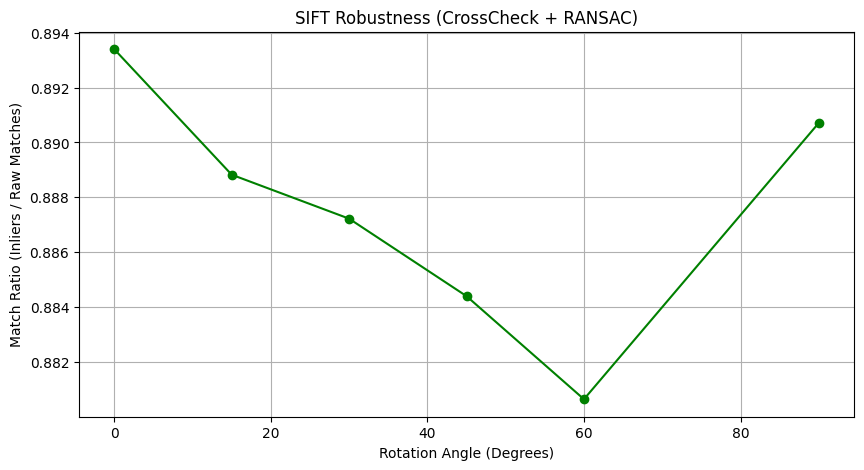

In [63]:
# --- CHANGE 1: Enable CrossCheck in the Matcher ---
# This replaces the need for Lowe's Ratio Test by ensuring mutual best matches
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

angles = [0, 15, 30, 45, 60,90]
match_ratios = []

print(f"{'Angle':<10} | {'Raw Matches':<15} | {'RANSAC Inliers':<15} | {'Ratio':<10}")
print("-" * 65)

for angle in angles:
    # 1. Transform: Rotate and Scale
    M_rot = cv2.getRotationMatrix2D((w/2, h/2), angle, 0.7)
    img2 = cv2.warpAffine(img1, M_rot, (w, h))
    gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

    # 2. Detect and Compute
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des2 is None:
        match_ratios.append(0)
        continue

    # --- CHANGE 2: Simple Match instead of KNN ---
    # Because crossCheck=True is enabled, we get high-quality matches immediately
    matches = bf.match(des1, des2)

    # --- CHANGE 3: No more Lowe's loop ---
    # We pass all cross-checked matches directly to RANSAC
    good_matches = matches

    # 3. Geometric Verification using RANSAC
    final_matches_count = 0
    if len(good_matches) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # findHomography acts as the ultimate 'datapoint checker'
        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        if mask is not None:
            # Count how many matches are geometrically consistent (inliers)
            final_matches_count = np.sum(mask)
    else:
        final_matches_count = len(good_matches)

    # 4. Calculate Ratio (RANSAC Inliers / Total Cross-Checked Matches)
    ratio = final_matches_count / len(matches) if len(matches) > 0 else 0
    match_ratios.append(ratio)

    print(f"{angle:<10} | {len(matches):<15} | {int(final_matches_count):<15} | {ratio:.3f}")

# --- Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(angles, match_ratios, marker='o', linestyle='-', color='g')
plt.title('SIFT Robustness (CrossCheck + RANSAC)')
plt.xlabel('Rotation Angle (Degrees)')
plt.ylabel('Match Ratio (Inliers / Raw Matches)')
plt.grid(True)
plt.show()

Scale      | Symmetry Match  | RANSAC Inlier   | Ratio
------------------------------------------------------------
1.0        | 2292            | 2104            | 0.9180
0.9        | 2247            | 2077            | 0.9243
0.8        | 2098            | 1940            | 0.9247
0.7        | 1688            | 1499            | 0.8880
0.5        | 902             | 753             | 0.8348
0.3        | 329             | 214             | 0.6505


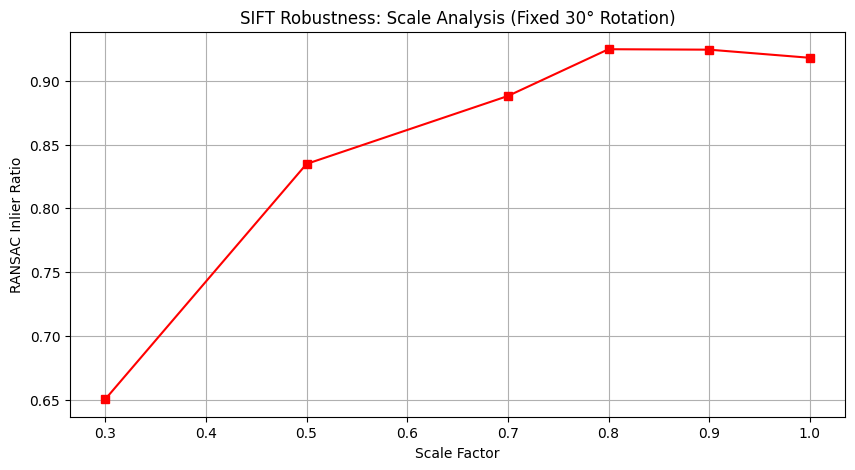

In [64]:
# 2. SCALE TEST (Fixed Rotation at 30 degrees)
scales = [1.0, 0.9, 0.8, 0.7, 0.5, 0.3]
scale_ratios = []

print(f"{'Scale':<10} | {'Symmetry Match':<15} | {'RANSAC Inlier':<15} | {'Ratio'}")
print("-" * 60)

for s in scales:
    # IMPORTANT: Always derive M from the ORIGINAL w, h
    M = cv2.getRotationMatrix2D((w/2, h/2), 30, s)
    
    # Apply transformation
    img2 = cv2.warpAffine(img1, M, (w, h), borderValue=(0,0,0))
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Detect features in the transformed image
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des2 is None:
        scale_ratios.append(0)
        continue

    # Match using Symmetry (Cross-Check)
    matches = bf.match(des1, des2)

    # Geometric Verification (RANSAC)
    inliers_count = 0
    if len(matches) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        if mask is not None:
            inliers_count = np.sum(mask)
    
    # Consistency Check: 
    # Use len(matches) as denominator to see how many "potential" matches were valid
    ratio = inliers_count / len(matches) if len(matches) > 0 else 0
    scale_ratios.append(ratio)

    print(f"{s:<10} | {len(matches):<15} | {int(inliers_count):<15} | {ratio:.4f}")

# 3. Visualization
plt.figure(figsize=(10, 5))
plt.plot(scales, scale_ratios, marker='s', color='red')
plt.title('SIFT Robustness: Scale Analysis (Fixed 30° Rotation)')
plt.xlabel('Scale Factor')
plt.ylabel('RANSAC Inlier Ratio')
plt.grid(True)
plt.show()

Sigma      | Symmetry Match  | RANSAC Inlier   | Ratio
------------------------------------------------------------
0          | 4670            | 4670            | 1.0000
1          | 1735            | 1467            | 0.8455
2          | 671             | 465             | 0.6930
3          | 389             | 214             | 0.5501
5          | 164             | 88              | 0.5366


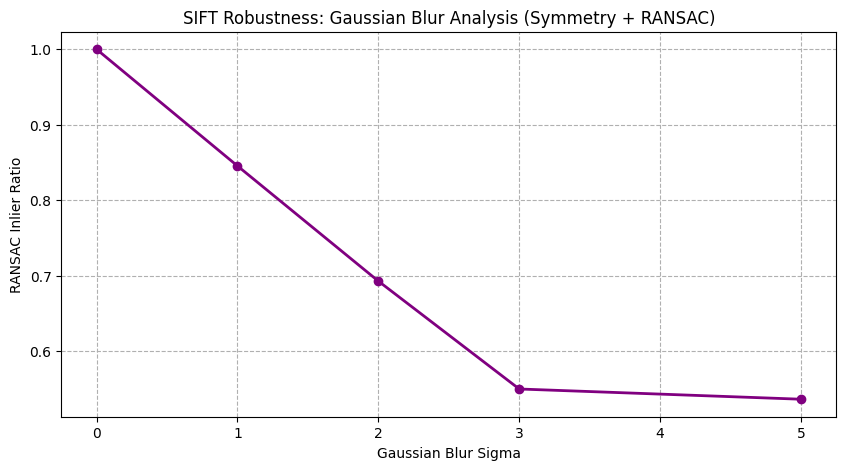

In [65]:
sigmas = [0, 1, 2, 3, 5]
blur_ratios = []

print(f"{'Sigma':<10} | {'Symmetry Match':<15} | {'RANSAC Inlier':<15} | {'Ratio'}")
print("-" * 60)

for s in sigmas:
    # 1. Apply Blur
    if s == 0:
        img_blur = img1.copy()
    else:
        img_blur = cv2.GaussianBlur(img1, (0,0), s)
    
    gray2 = cv2.cvtColor(img_blur, cv2.COLOR_BGR2GRAY)

    # 2. Detect & Compute
    kp2, des2 = sift.detectAndCompute(gray2, None)

    if des2 is None:
        blur_ratios.append(0)
        continue

    # 3. Match with Symmetry (Cross-Check)
    # This removes ambiguous matches without needing the 0.75 threshold
    matches = bf.match(des1, des2)

    # 4. RANSAC Geometric Verification
    inliers_count = 0
    if len(matches) > 10:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

        # In this test, RANSAC expects the transformation to be the Identity Matrix.
        # It will kill any match that has 'drifted' due to blur.
        _, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        
        if mask is not None:
            inliers_count = np.sum(mask)
    else:
        inliers_count = len(matches)

    # 5. Calculate Ratio (Inliers / Total Raw Matches)
    ratio = inliers_count / len(matches) if len(matches) > 0 else 0
    blur_ratios.append(ratio)

    print(f"{s:<10} | {len(matches):<15} | {int(inliers_count):<15} | {ratio:.4f}")

# --- 3. VISUALIZATION ---
plt.figure(figsize=(10, 5))
plt.plot(sigmas, blur_ratios, marker='o', color='purple', linewidth=2)
plt.title('SIFT Robustness: Gaussian Blur Analysis (Symmetry + RANSAC)')
plt.xlabel('Gaussian Blur Sigma')
plt.ylabel('RANSAC Inlier Ratio')
plt.grid(True, linestyle='--')
plt.show() 